In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [65]:
df = pd.read_csv('GaltonFamilies.csv')
df.head()

,rownames,family,father,mother,midparentHeight,children,childNum,gender,childHeight
0,1,001,78.5,67.0,75.43,4,1,male,73.2
1,2,001,78.5,67.0,75.43,4,2,female,69.2
2,3,001,78.5,67.0,75.43,4,3,female,69.0
3,4,001,78.5,67.0,75.43,4,4,female,69.0
4,5,002,75.5,66.5,73.66,4,1,male,73.5


In [66]:
mothers = df.drop_duplicates(subset='family')['mother'].values.astype(float)
children = df['childHeight'].values.astype(float)

print(f"Mothers: n = {len(mothers)}")
print(f"Children: n = {len(children)}")


Mothers: n = 205
Children: n = 934


In [67]:
# one unlabeled array
X = np.concatenate([mothers, children])

print(f"\nAggregated dataset: n = {len(X)}, range = [{X.min():.1f}, {X.max():.1f}] inches")


Aggregated dataset: n = 1139, range = [56.0, 79.0] inches


In [68]:
def gaussian_pdf(x, mu, sigma):
    return (1.0 / np.sqrt(2 * np.pi * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma))

In [69]:
def log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2):
    mix = pi1 * gaussian_pdf(X, mu1, var1) + pi2 * gaussian_pdf(X, mu2, var2)
    return np.sum(np.log(mix))

In [70]:
def init_params(X, seed=42):
  rng = np.random.default_rng(seed)
  mu1, mu2 = rng.choice(X, size=2, replace=False)
  var1 = var2 = np.var(X)
  pi1 = pi2 = 0.5
  return mu1, mu2, var1, var2, pi1, pi2

In [71]:
def em_gmm(X, n_iters=30, seed=42):
    mu1, mu2, var1, var2, pi1, pi2 = init_params(X, seed)
    ll = log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2)

    history = [{'iter': 0, 'mu1': mu1, 'mu2': mu2, 'var1': var1, 'var2': var2,
                'pi1': pi1, 'pi2': pi2, 'log_likelihood': ll}]

    for it in range(1, n_iters + 1):
        # E-STEP
        p1 = pi1 * gaussian_pdf(X, mu1, var1)
        p2 = pi2 * gaussian_pdf(X, mu2, var2)
        total = p1 + p2
        gamma1 = p1 / total
        gamma2 = p2 / total

        # M-STEP
        N1, N2 = gamma1.sum(), gamma2.sum()

        mu1 = np.sum(gamma1 * X) / N1
        mu2 = np.sum(gamma2 * X) / N2

        var1 = np.sum(gamma1 * (X - mu1) ** 2) / N1
        var2 = np.sum(gamma2 * (X - mu2) ** 2) / N2

        pi1 = N1 / len(X)
        pi2 = N2 / len(X)

        ll = log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2)
        history.append({'iter': it, 'mu1': mu1, 'mu2': mu2, 'var1': var1, 'var2': var2,
                         'pi1': pi1, 'pi2': pi2, 'log_likelihood': ll})

    return mu1, mu2, var1, var2, pi1, pi2, history


mu1, mu2, var1, var2, pi1, pi2, history = em_gmm(X, n_iters=30)

if mu1 > mu2:
    mu1, mu2 = mu2, mu1
    var1, var2 = var2, var1
    pi1, pi2 = pi2, pi1

print("Converged parameters:")
print(f"  mu1 (Children) = {mu1:.3f}   var1 = {var1:.3f}   pi1 = {pi1:.3f}")
print(f"  mu2 (Mothers)  = {mu2:.3f}   var2 = {var2:.3f}   pi2 = {pi2:.3f}")
print(f"  final log-likelihood = {history[-1]['log_likelihood']:.3f}")

Converged parameters:
  mu1 (Children) = 63.598   var1 = 4.738   pi1 = 0.434
  mu2 (Mothers)  = 68.290   var2 = 9.039   pi2 = 0.566
  final log-likelihood = -3038.277


In [72]:
# Tracking table
table = pd.DataFrame(history[:3])
table = table.rename(columns={
    'mu1': 'mu1 (Children)', 'mu2': 'mu2 (Mothers)',
    'var1': 'sigma1^2', 'var2': 'sigma2^2', 'pi1': 'pi1', 'pi2': 'pi2',
    'log_likelihood': 'Log-Likelihood'
})
table['iter'] = ['0 (Initialization)', '1', '2']
table = table.rename(columns={'iter': 'Iteration'})
table = table[['Iteration', 'mu1 (Children)', 'mu2 (Mothers)', 'sigma1^2', 'sigma2^2', 'pi1', 'pi2', 'Log-Likelihood']]
table.round(4)

,Iteration,mu1 (Children),mu2 (Mothers),sigma1^2,sigma2^2,pi1,pi2,Log-Likelihood
0,0 (Initialization),66.0000,63.5000,12.5802,12.5802,0.5000,0.5000,-3152.7638
1,1,67.2334,64.9753,12.0962,10.3267,0.5654,0.4346,-3055.3302
2,2,67.2582,64.9472,12.5212,9.6411,0.5646,0.4354,-3053.9400


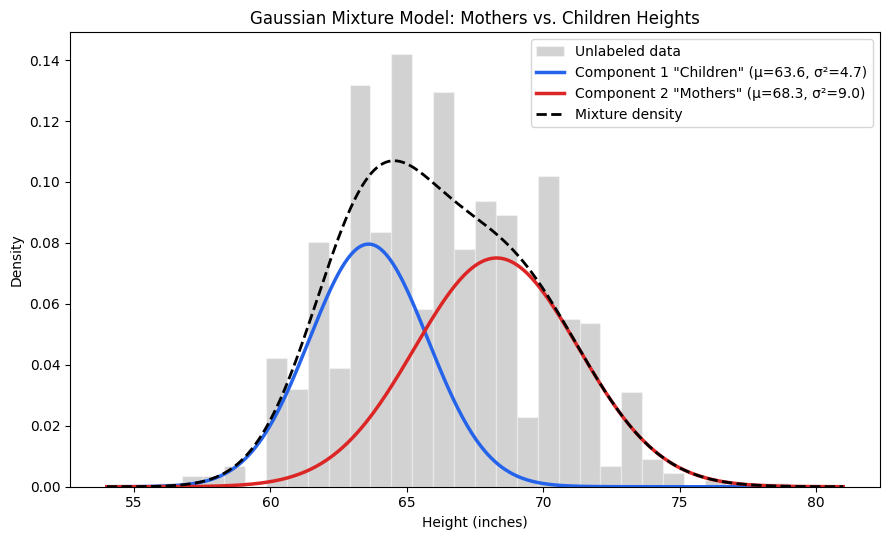

In [73]:
# Data visualization
x_grid = np.linspace(X.min() - 2, X.max() + 2, 500)

pdf1 = pi1 * gaussian_pdf(x_grid, mu1, var1)
pdf2 = pi2 * gaussian_pdf(x_grid, mu2, var2)
pdf_mix = pdf1 + pdf2

plt.figure(figsize=(9, 5.5))
plt.hist(X, bins=30, density=True, alpha=0.35, color='gray', edgecolor='white',
         label='Unlabeled data')

plt.plot(x_grid, pdf1, lw=2.5, color='#2563eb', label=f'Component 1 "Children" (μ={mu1:.1f}, σ²={var1:.1f})')
plt.plot(x_grid, pdf2, lw=2.5, color='#dc2626', label=f'Component 2 "Mothers" (μ={mu2:.1f}, σ²={var2:.1f})')
plt.plot(x_grid, pdf_mix, lw=2, color='black', ls='--', label='Mixture density')

plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.title('Gaussian Mixture Model: Mothers vs. Children Heights')
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
def classify_height(x_new, mu1, mu2, var1, var2, pi1, pi2):
    p1 = pi1 * gaussian_pdf(x_new, mu1, var1)
    p2 = pi2 * gaussian_pdf(x_new, mu2, var2)
    total = p1 + p2
    post1 = p1 / total
    post2 = p2 / total
    return post1, post2


test_height = 63

post_child, post_mother = classify_height(test_height, mu1, mu2, var1, var2, pi1, pi2)

print(f"Test height: {test_height} inches\n")
print(f"P(Child  | x={test_height}) = {post_child:.4f}")
print(f"P(Mother | x={test_height}) = {post_mother:.4f}")
print(f"\n Model classifies this as: {'CHILD' if post_child > post_mother else 'MOTHER'}")

Test height: 63 inches

P(Child  | x=63) = 0.8277
P(Mother | x=63) = 0.1723

 Model classifies this as: CHILD
